
=== SEGMENT DISTRIBUTION ===
Segment
Low Value              2028
About to Sleep         1131
Champions              1122
Hibernating            1109
Loyal Customers         938
Potential Loyalists     658
Need Attention          346
Promising               231
At Risk                 181
Can't Lose              119
New Customers            40
Name: count, dtype: int64

=== RFM HEAD ===
             Recency  Frequency  Monetary  R_score  F_score  M_score  \
customer_id                                                            
C10000             5          2    210.58        5        1        2   
C10001           194          5   3246.02        2        3        5   
C10002           401          5    216.85        1        3        2   
C10003            72          3    154.30        4        1        1   
C10004           600          3    716.99        1        1        4   

            RFM_Score  RFM_Total         Segment  
customer_id                                       
C10

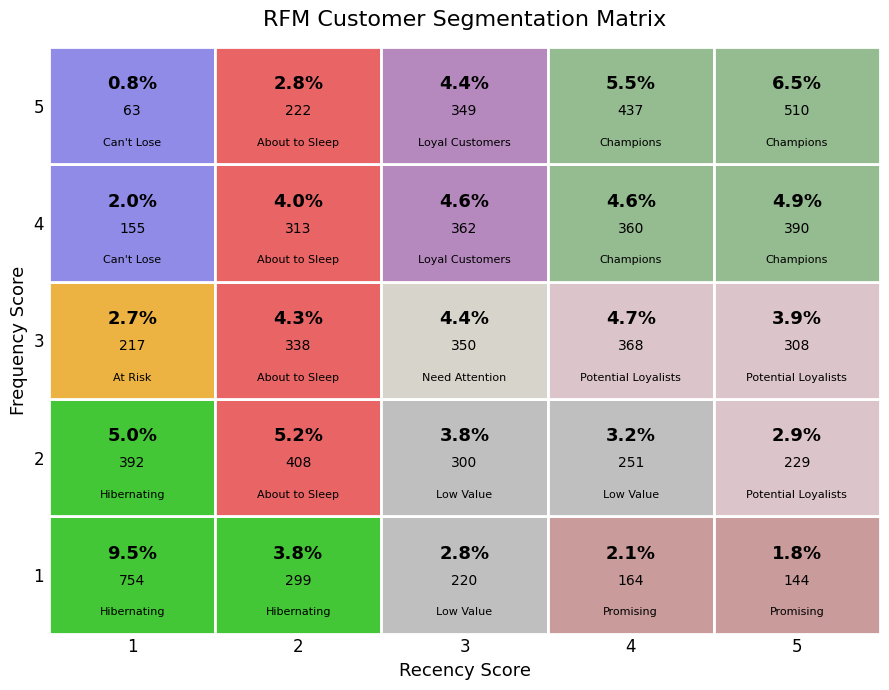

In [ ]:
import pandas as pd
import numpy as np
from matplotlib.patches import Rectangle
import matplotlib.pyplot as plt

# 1. LOAD DATA
df = pd.read_csv("ecommerce_sales_34500.csv")

# 2. PREPROCESSING
df["order_date"] = pd.to_datetime(df["order_date"], errors="coerce")
df = df.dropna(subset=["customer_id", "order_id", "order_date", "total_amount"])
df = df[df["total_amount"] > 0].copy()

# 3. RFM TABLE
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg({
    "order_date": lambda x: (snapshot_date - x.max()).days,
    "order_id": "count",
    "total_amount": "sum"
}).rename(columns={
    "order_date": "Recency",
    "order_id": "Frequency",
    "total_amount": "Monetary"
})

# 4. RFM SCORING (QUINTILES 1-5)
# Recency: thấp hơn là tốt hơn
rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: cao hơn là tốt hơn
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: cao hơn là tốt hơn
rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)
rfm["RFM_Total"] = rfm[["R_score", "F_score", "M_score"]].sum(axis=1)

# 5. SEGMENTATION RULES (DỰA TRÊN CẢ R, F, M)
def segment_customer(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]


    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"

    elif r >= 3 and f >= 4 and m >= 3:
        return "Loyal Customers"

    elif r >= 4 and f >= 2 and m >= 3:
        return "Potential Loyalists"

    elif r == 5 and f == 1 and m >= 3:
        return "New Customers"

    elif r >= 4 and f == 1 and m <= 2:
        return "Promising"

    elif r == 3 and f >= 2 and m >= 3:
        return "Need Attention"

    elif r == 2 and f >= 2 and m >= 2:
        return "About to Sleep"

    elif r <= 2 and f >= 4 and m >= 4:
        return "Can't Lose"

    elif r <= 2 and f >= 3 and m >= 3:
        return "At Risk"

    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"

    else:
        return "Low Value"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

# 6. SUMMARY
print("\n=== SEGMENT DISTRIBUTION ===")
print(rfm["Segment"].value_counts())

print("\n=== RFM HEAD ===")
print(rfm.head())

# 7. COLOR MAP
segment_colors = {
    "Champions": "#95bb90",
    "Loyal Customers": "#b589bd",
    "Potential Loyalists": "#dbc4ca",
    "New Customers": "#9eaddb",
    "Promising": "#c99b9b",
    "Need Attention": "#d7d4cb",
    "About to Sleep": "#E96565",
    "At Risk": "#ecb342",
    "Hibernating": "#44c736",
    "Can't Lose": "#8f8be6",
    "Low Value": "#bfbfbf"
}

# 8. TẠO MA TRẬN 5x5 THEO KẾT QUẢ THỰC
# Lưu ý: biểu đồ vẫn là ma trận Recency x Frequency,
# nhưng segment trong từng ô đã được gán bằng cả 3 chỉ số R, F, M.
cell_summary = (
    rfm.groupby(["F_score", "R_score"])
    .agg(
        customers=("Segment", "size"),
        dominant_segment=("Segment", lambda x: x.value_counts().idxmax())
    )
    .reset_index()
)

total_customers = len(rfm)
cell_summary["pct"] = cell_summary["customers"] / total_customers * 100

# Bổ sung các ô còn thiếu để đủ 5x5
all_cells = pd.MultiIndex.from_product(
    [range(1, 6), range(1, 6)],
    names=["F_score", "R_score"]
).to_frame(index=False)

cell_summary = all_cells.merge(cell_summary, on=["F_score", "R_score"], how="left")

cell_summary["customers"] = cell_summary["customers"].fillna(0).astype(int)
cell_summary["pct"] = cell_summary["pct"].fillna(0)

# Nếu ô không có khách hàng, gán segment theo rule với Monetary trung vị (=3) để màu vẫn logic
def infer_segment_from_cell(f_score, r_score, m_score=3):
    temp = pd.Series({"F_score": f_score, "R_score": r_score, "M_score": m_score})
    return segment_customer(temp)

cell_summary["dominant_segment"] = cell_summary.apply(
    lambda row: row["dominant_segment"]
    if pd.notna(row["dominant_segment"])
    else infer_segment_from_cell(row["F_score"], row["R_score"]),
    axis=1
)

cell_summary["color"] = cell_summary["dominant_segment"].map(segment_colors)

# 9. VISUALIZATION: MA TRẬN R x F
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
ax.grid(False)

for _, row in cell_summary.iterrows():
    x = row["R_score"] - 1
    y = row["F_score"] - 1

    rect = Rectangle(
        (x, y), 1, 1,
        facecolor=row["color"],
        edgecolor="white",
        linewidth=2
    )
    ax.add_patch(rect)

    if row["customers"] > 0:
        ax.text(
            x + 0.5, y + 0.68,
            f"{row['pct']:.1f}%",
            ha="center", va="center",
            fontsize=13, fontweight="bold", color="black"
        )
        ax.text(
            x + 0.5, y + 0.45,
            f"{row['customers']:,}",
            ha="center", va="center",
            fontsize=10, color="black"
        )
        ax.text(
            x + 0.5, y + 0.18,
            row["dominant_segment"],
            ha="center", va="center",
            fontsize=8, color="black", wrap=True
        )
    else:
        ax.text(
            x + 0.5, y + 0.5,
            row["dominant_segment"],
            ha="center", va="center",
            fontsize=8, color="gray", wrap=True
        )

ax.set_xticks(np.arange(0.5, 5.5, 1))
ax.set_xticklabels([1, 2, 3, 4, 5], fontsize=12)
ax.set_yticks(np.arange(0.5, 5.5, 1))
ax.set_yticklabels([1, 2, 3, 4, 5], fontsize=12)

ax.set_xlabel("Recency Score", fontsize=13)
ax.set_ylabel("Frequency Score", fontsize=13)
ax.set_title("RFM Customer Segmentation Matrix", fontsize=16, pad=15)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(length=0)

plt.tight_layout()
plt.show()

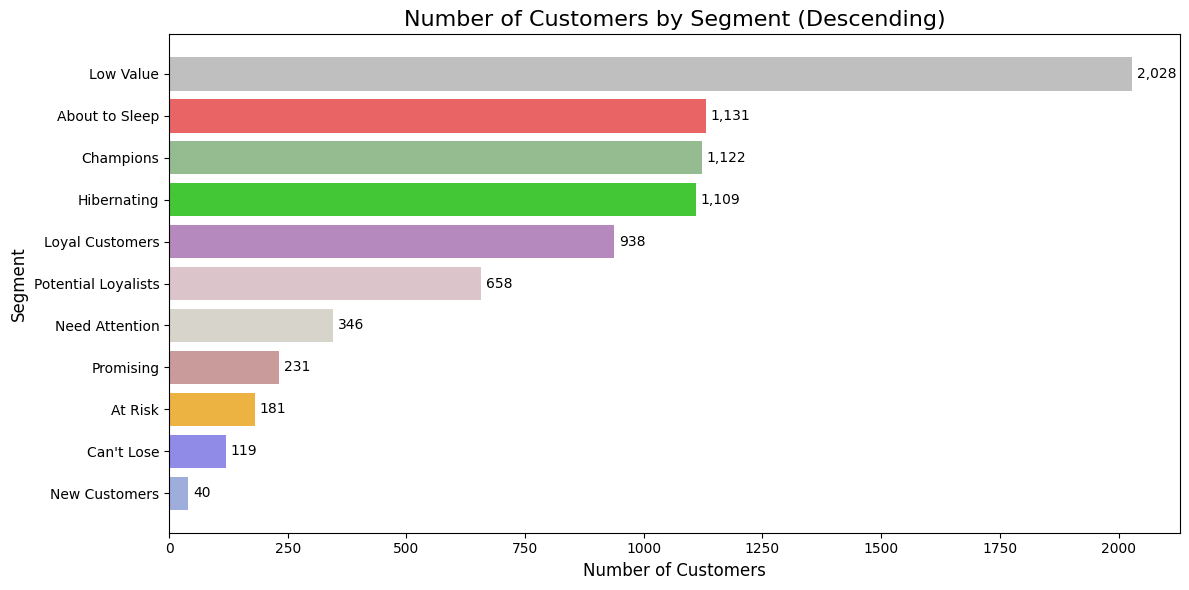

In [10]:
# Sắp xếp giảm dần theo số lượng
segment_counts = rfm["Segment"].value_counts().sort_values(ascending=False)

# Nếu thiếu màu ở segment nào thì dùng màu mặc định xám
bar_colors = [segment_colors.get(seg, "#999999") for seg in segment_counts.index]

plt.figure(figsize=(12, 6))
bars = plt.barh(segment_counts.index, segment_counts.values, color=bar_colors)

plt.title("Number of Customers by Segment (Descending)", fontsize=16)
plt.xlabel("Number of Customers", fontsize=12)
plt.ylabel("Segment", fontsize=12)

# Thanh lớn nhất nằm trên cùng
plt.gca().invert_yaxis()

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + max(segment_counts.values) * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,}",
        va="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_9288\3064743439.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


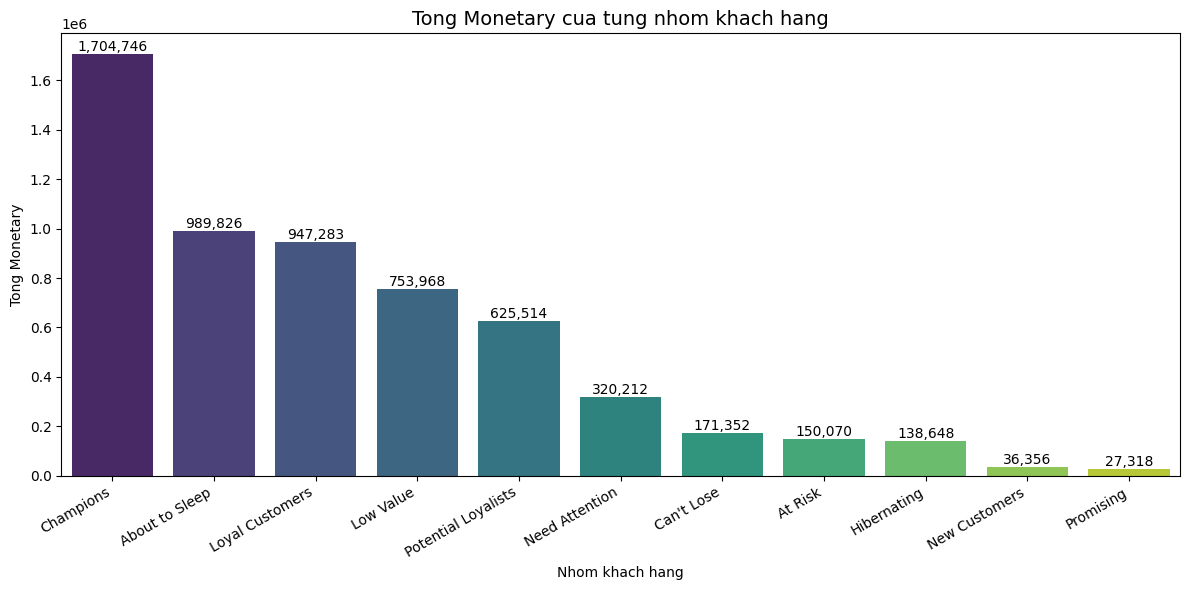

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tổng Monetary theo từng nhóm khách hàng
segment_monetary = (
    rfm.groupby("Segment", as_index=False)["Monetary"]
    .sum()
    .sort_values("Monetary", ascending=False)
)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=segment_monetary,
    x="Segment",
    y="Monetary",
    palette="viridis"
)

# Hiển thị giá trị trên đầu cột
for i, v in enumerate(segment_monetary["Monetary"]):
    ax.text(i, v, f"{v:,.0f}", ha="center", va="bottom", fontsize=10)

plt.title("Tong Monetary cua tung nhom khach hang", fontsize=14)
plt.xlabel("Nhom khach hang")
plt.ylabel("Tong Monetary")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
